In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

2025-02-16 01:33:42.185575: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-16 01:33:42.379113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739698422.467096   32250 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739698422.485941   32250 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-16 01:33:42.631073: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [ ]:
def load_data(file_path):
    """
    Load the CSV file containing embeddings and labels.
    """
    df = pd.read_csv(file_path)

    # Convert embeddings from strings to NumPy arrays
    df["embedding"] = df["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=","))

    # Convert labels: "1,0" -> 1 (Normal), "0,1" -> 0 (Abnormal)
    df["label"] = df["label"].apply(lambda x: 1 if x == "1,0" else 0)

    # Convert to NumPy arrays
    embeddings = np.stack(df["embedding"].values)
    labels = np.array(df["label"].values)

    # Split into train/test (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, labels, test_size=0.2, random_state=42
    )

    # Create TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(64).shuffle(1000).prefetch(tf.data.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(64).prefetch(tf.data.AUTOTUNE)

    print(f"✅ Data loaded: {len(X_train)} training samples, {len(X_test)} testing samples")

    # Verify shapes
    for x, y in train_ds.take(1):
        print(f"Batch shapes: X={x.shape}, y={y.shape}")

    return train_ds, test_ds, X_train.shape[1]

# Load data
train_ds, test_ds, input_dim = load_data("~/final_merged_data.csv")

✅ Data loaded: 5464 training samples, 1366 testing samples
Batch shapes: X=(64, 1408), y=(64,)


2025-02-16 01:34:13.423985: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

# Assume input_dim is defined (e.g., number of features in your embeddings)
input_dim = 1408  # update this as needed


def residual_block(x, hp, block_id):
    """
    A residual block that preserves the input shape.
    """
    units = int(x.shape[-1])
    # First part of the residual block
    y = layers.Dense(units, activation="relu", name=f"res_{block_id}_dense_1")(x)
    y = layers.BatchNormalization(name=f"res_{block_id}_bn_1")(y)
    # Second part of the block
    y = layers.Dense(units, activation="relu", name=f"res_{block_id}_dense_2")(y)
    y = layers.BatchNormalization(name=f"res_{block_id}_bn_2")(y)
    # Define dropout inside the residual block
    res_dropout = hp.Float(f"res_dropout_{block_id}", min_value=0.2, max_value=0.5, step=0.1)
    y = layers.Dropout(res_dropout, name=f"res_{block_id}_dropout")(y)
    # Add the skip connection
    out = layers.Add(name=f"res_{block_id}_add")([x, y])
    return out

def build_model(hp):
    inputs = keras.Input(shape=(input_dim,), name="input_layer")
    
    # Dense Layer 1: Units between 812 and 1048 with dropout
    units_1 = hp.Int("units_1", min_value=812, max_value=1048, step=32)
    x = layers.Dense(units_1, activation="relu", name="dense_1")(inputs)
    dropout_1 = hp.Float("dropout_1", min_value=0.2, max_value=0.5, step=0.1)
    x = layers.Dropout(dropout_1, name="dropout_1")(x)
    
    # Dense Layer 2: Units between 512 and units_1 with dropout
    units_2 = hp.Int("units_2", min_value=512, max_value=units_1, step=32)
    x = layers.Dense(units_2, activation="relu", name="dense_2")(x)
    dropout_2 = hp.Float("dropout_2", min_value=0.2, max_value=0.5, step=0.1)
    x = layers.Dropout(dropout_2, name="dropout_2")(x)
    
    # Add the first residual block after Dense Layer 2
    num_residual = hp.Choice("num_residual", values=[1, 2])
    x = residual_block(x, hp, block_id=0)
    
    # Dense Layer 3: Units between 256 and units_2 with dropout
    units_3 = hp.Int("units_3", min_value=256, max_value=units_2, step=32)
    x = layers.Dense(units_3, activation="relu", name="dense_3")(x)
    dropout_3 = hp.Float("dropout_3", min_value=0.2, max_value=0.5, step=0.1)
    x = layers.Dropout(dropout_3, name="dropout_3")(x)
    
    # Dense Layer 4: Fixed at 128 units with dropout
    units_4 = 128
    x = layers.Dense(units_4, activation="relu", name="dense_4")(x)
    dropout_4 = hp.Float("dropout_4", min_value=0.2, max_value=0.5, step=0.1)
    x = layers.Dropout(dropout_4, name="dropout_4")(x)
    
    # Optionally add a second residual block after Dense Layer 4
    if num_residual == 2:
        x = residual_block(x, hp, block_id=1)
    
    # Final output layer
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs, name="automl_dense_dropout_model")
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Float("learning_rate", min_value=1e-5, max_value=1e-2, sampling="LOG")
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model



# To start the search, use your training and validation datasets.
# For example, if you already have tf.data.Dataset objects train_ds and test_ds:
# tuner.search(train_ds, epochs=20, validation_data=test_ds)

# After search, you can retrieve the best model and hyperparameters:
# best_model = tuner.get_best_models(num_models=1)[0]
# best_hps = tuner.oracle.get_best_trials(num_trials=1)[0].hyperparameters.values
# print("Best Hyperparameters:", best_hps)


In [6]:
# ==============================
# 🔍 Run Hyperparameter Tuning
# ==============================

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=10,
        mode="max",
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=5,
        mode="max",
        min_lr=1e-6
    )
]


def run_tuning(train_ds, val_ds):
    # Set up the Keras Tuner (Hyperband is used here).
    tuner = kt.Hyperband(
        build_model,
        objective="val_accuracy",
        max_epochs=30,
        factor=3,
        directory="my_tuner_dir",
        project_name="residual_custom_model"
    )

    tuner.search(train_ds, epochs=30, validation_data=val_ds, callbacks=callbacks)

    # Get best model
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_model = tuner.hypermodel.build(best_hps)
    return best_model

# Train Final Model with Best Parameters
best_model = run_tuning(train_ds, test_ds)

# ==============================
# 🚀 Train Best Model
# ==============================
history = best_model.fit(train_ds, epochs=30, validation_data=test_ds)

# Save Model
best_model.save("best_residual_mlp.h5")

Reloading Tuner from my_tuner_dir/residual_custom_model/tuner0.json
Epoch 1/30


I0000 00:00:1739698461.877775   32356 service.cc:148] XLA service 0x7f025800b620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739698461.878581   32356 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2025-02-16 01:34:21.962976: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1739698462.284633   32356 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/86 ━━━━━━━━━━━━━━━━━━━━ 6:29 5s/step - accuracy: 0.5156 - loss: 1.1880

I0000 00:00:1739698464.522527   32356 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


84/86 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6108 - loss: 1.0536  

2025-02-16 01:34:28.760279: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_81', 16 bytes spill stores, 16 bytes spill loads

2025-02-16 01:34:28.831290: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_88', 176 bytes spill stores, 176 bytes spill loads

2025-02-16 01:34:28.856771: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_81', 4 bytes spill stores, 4 bytes spill loads

2025-02-16 01:34:29.007565: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_81_0', 252 bytes spill stores, 252 bytes spill loads

2025-02-16 01:34:29.084450: I external/local_xla/xla/stream_exec

86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 119ms/step - accuracy: 0.6125 - loss: 1.0466 - val_accuracy: 0.7504 - val_loss: 0.5624
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7080 - loss: 0.6192 - val_accuracy: 0.7174 - val_loss: 0.5318
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7048 - loss: 0.5601 - val_accuracy: 0.7013 - val_loss: 0.5725
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7372 - loss: 0.5354 - val_accuracy: 0.7343 - val_loss: 0.5246
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7482 - loss: 0.5171 - val_accuracy: 0.7357 - val_loss: 0.5289
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7521 - loss: 0.5117 - val_accuracy: 0.7445 - val_loss: 0.5046
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7493 - loss: 0.5056 - val_accuracy: 0.7533 - val_loss: 0.5078
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7378 - loss: 0.5194 - val_accuracy: 0.7504 - val_loss: 0.5042


In [6]:
# show model summary
best_model.summary()

for layer in best_model.layers:
    if isinstance(layer, tf.keras.layers.Dropout):
        print(f"Layer {layer.name} has dropout rate: {layer.rate}")

Model: "automl_dense_dropout_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1408)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 972)       │  1,369,548 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 972)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 576)       │    560,448 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 576)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_0_dense_1       │ (None, 576)       │    332,352 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_0_bn_1          │ (None, 576)       │      2,304 │ res_0_dense_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_0_dense_2       │ (None, 576)       │    332,352 │ res_0_bn_1[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_0_bn_2          │ (None, 576)       │      2,304 │ res_0_dense_2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_0_dropout       │ (None, 576)       │          0 │ res_0_bn_2[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_0_add (Add)     │ (None, 576)       │          0 │ dropout_2[0][0],  │
│                     │                   │            │ res_0_dropout[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 320)       │    184,640 │ res_0_add[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 320)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     41,088 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_1_dense_1       │ (None, 128)       │     16,512 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_1_bn_1          │ (None, 128)       │        512 │ res_1_dense_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_1_dense_2       │ (None, 128)       │     16,512 │ res_1_bn_1[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_1_bn_2          │ (None, 128)       │        512 │ res_1_dense_2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 8,572,009 (32.70 MB)

 Trainable params: 2,856,397 (10.90 MB)

 Non-trainable params: 2,816 (11.00 KB)

 Optimizer params: 5,712,796 (21.79 MB)

Layer dropout_1 has dropout rate: 0.4
Layer dropout_2 has dropout rate: 0.30000000000000004
Layer res_0_dropout has dropout rate: 0.2
Layer dropout_3 has dropout rate: 0.4
Layer dropout_4 has dropout rate: 0.2
Layer res_1_dropout has dropout rate: 0.4


In [7]:
# ==============================
# 🚀 4️⃣ Train the Model 
# ==============================

early_stopping = keras.callbacks.EarlyStopping(monitor="val_auc", patience=5, restore_best_weights=True)

def train_model(model, train_ds, test_ds, epochs=50):
    """Train the neural network on the dataset."""
    history = model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=epochs,
        verbose=1
    )
    print("✅ Training completed!")
    return history

# Train the model
history = train_model(best_model, train_ds, test_ds)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.7503 - loss: 0.4903 - val_accuracy: 0.7476 - val_loss: 0.5331
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7665 - loss: 0.4954 - val_accuracy: 0.7471 - val_loss: 0.5227
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7572 - loss: 0.4836 - val_accuracy: 0.7508 - val_loss: 0.5348
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7700 - loss: 0.4875 - val_accuracy: 0.7445 - val_loss: 0.5476
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7743 - loss: 0.4462 - val_accuracy: 0.7366 - val_loss: 0.5467
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7318 - loss: 0.4786 - val_accuracy: 0.7234 - val_loss: 0.5555
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7416 - loss: 0.4681 - val_accuracy: 0.7393 - val_loss: 0.5802
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7542 - loss: 0.4466 - val_accuracy: 0.6930 - val_loss: 0.6031

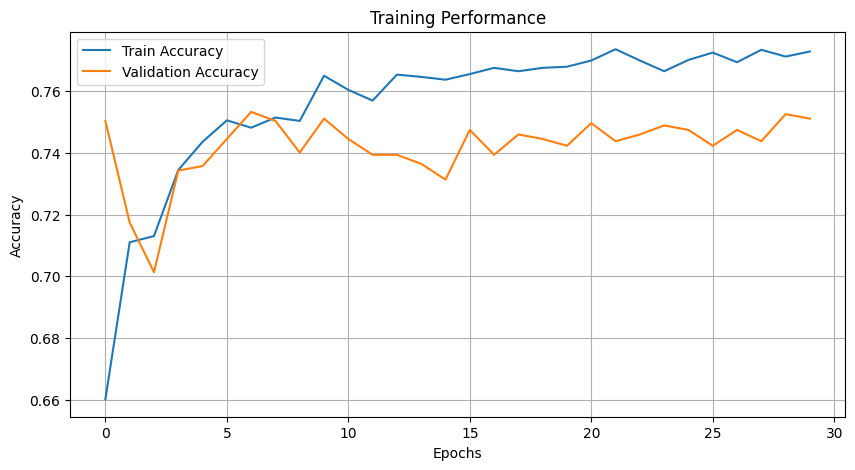

In [7]:
# ==============================
# 📈 5️⃣ Plot Training Performance
# ==============================

import matplotlib.pyplot as plt

def plot_training_history(history):
    """Plot accuracy and loss over training epochs."""
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training Performance")
    plt.grid(True)
    plt.show()

# Plot the results
plot_training_history(history)


2025-02-16 01:34:53.971944: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_72', 244 bytes spill stores, 244 bytes spill loads

2025-02-16 01:34:54.263897: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_79', 28 bytes spill stores, 28 bytes spill loads

2025-02-16 01:34:54.780034: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_79', 272 bytes spill stores, 272 bytes spill loads

2025-02-16 01:34:54.890366: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_72', 368 bytes spill stores, 400 bytes spill loads

2025-02-16 01:34:54.937928: I external/local_xla/xla/stream_ex

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step


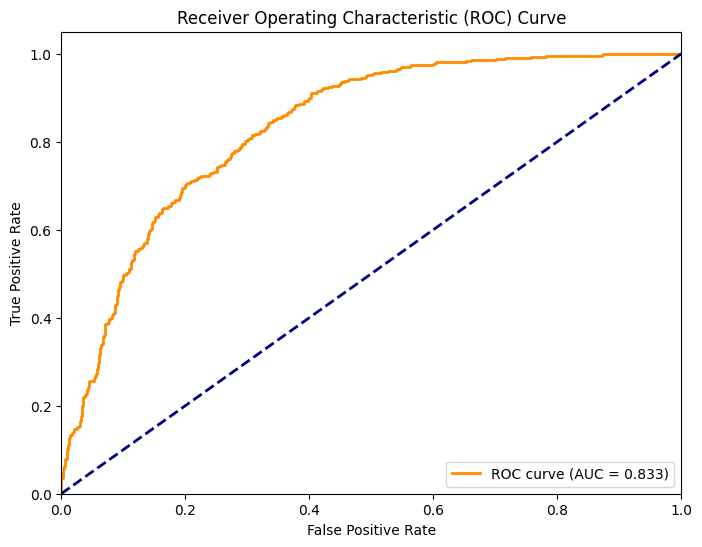

✅ Model AUC Score: 0.833


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, test_ds, input_dim):
    # Convert the dataset to a list so it can be reused.
    # This will unbatch the dataset, yielding tuples (features, labels).
    test_data = list(test_ds.unbatch().as_numpy_iterator())
    
    # Check if any data was extracted.
    if len(test_data) == 0:
        print("Test dataset is empty. Please check your data loading pipeline.")
        return
    
    # Unzip the data into features and labels
    test_features, test_labels = zip(*test_data)
    
    # Convert lists to NumPy arrays
    test_features = np.array(test_features).reshape(-1, input_dim)
    test_labels = np.array(test_labels).reshape(-1)
    
    # Make predictions on the test data
    y_pred = model.predict(test_features)
    
    # If your model has a single output, y_pred will be shape (n,1). Flatten if needed.
    if y_pred.ndim > 1 and y_pred.shape[1] == 1:
        y_pred = y_pred.flatten()
    
    # Compute ROC curve and AUC score
    fpr, tpr, _ = roc_curve(test_labels, y_pred)
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()
    
    print(f"✅ Model AUC Score: {roc_auc:.3f}")

# Call the function with the model and test dataset.
plot_roc_curve(best_model, test_ds, input_dim)
